In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import pickle
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


#### Lectura de train y test

In [2]:
df = pd.read_csv(r'C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\data\processed\dfdefinitivo.csv')
df.head()

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions,PI_High,PI_Low,AtR_High,AtR_Low,Exam_Score
0,0,4,7,1,0,0,0,1,9
1,1,27,13,0,0,1,0,0,3
2,1,25,6,1,1,0,0,0,9
3,1,13,11,1,0,0,0,0,2
4,2,23,1,1,0,1,1,0,7


#### Dividimos en train y test

In [3]:
X = df.drop(columns = 'Exam_Score')
poly = PolynomialFeatures(degree = 2)
X = poly.fit_transform(X)
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 30)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 45)
(2000, 45)
(8000,)
(2000,)


### Buscamos el mejor de los modelos

In [5]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge()) 
])

param_grid = [
    {
        'model': [Ridge()],
        'model__alpha': [0.1, 1, 10],
        'model__solver': ['auto', 'svd']
    },
    {
        'model': [Lasso()],
        'model__alpha': [0.001, 0.01, 0.1],
        'model__max_iter': [1000, 2000]
    },
    {
        'model': [RandomForestRegressor()],
        'model__n_estimators': [50, 100],
        'model__max_depth': [None, 5, 10]
    }
]

In [7]:
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_mean_absolute_error')

In [8]:
grid_search.fit(X_train, y_train)

c:\Users\plaza\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.340e+04, tolerance: 5.340e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\plaza\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.380e+04, tolerance: 5.372e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\plaza\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', Ridge())]),
             param_grid=[{'model': [Ridge()], 'model__alpha': [0.1, 1, 10],
                          'model__solver': ['auto', 'svd']},
                         {'model': [Lasso()],
                          'model__alpha': [0.001, 0.01, 0.1],
                          'model__max_iter': [1000, 2000]},
                         {'model': [RandomForestRegressor()],
                          'model__max_depth': [None, 5, 10],
                          'model__n_estimators': [50, 100]}],
             scoring='neg_mean_absolute_error')

In [9]:
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor score (MSE): {-grid_search.best_score_}")

Mejores parámetros: {'model': RandomForestRegressor(), 'model__max_depth': 10, 'model__n_estimators': 100}
Mejor score (MSE): 3.3070199724828284


#### Comprobamos qué tal lo hace con el test

<Axes: xlabel='Exam_Score'>

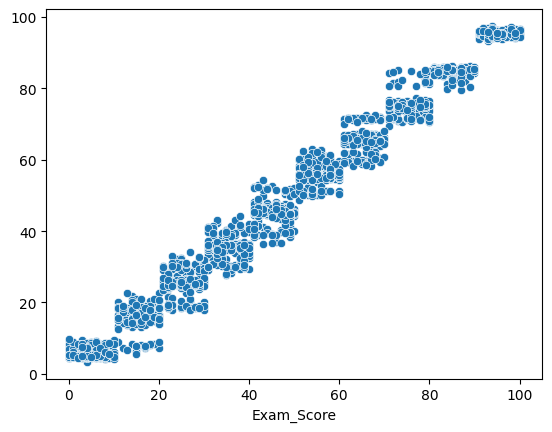

In [23]:
y_pred = grid_search.best_estimator_.predict(X_test)
sns.scatterplot(x = y_test, y = y_pred)

In [14]:
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 3.253803430803127
MSE: 16.33966314033437
RMSE: 4.042234918993993


#### Hacemos unas pruebas con nuevos datos inventados, serían outlayers

In [17]:
grid_search.best_estimator_.predict(poly.fit_transform([[0, 0, 73, 3, 1, 0, 0, 0]]))

array([40.26723321])

In [18]:
grid_search.best_estimator_.predict(poly.fit_transform([[0, 100, 0, 3, 1, 0, 0, 0]]))

array([13.8804581])

In [22]:
grid_search.best_estimator_.predict(poly.fit_transform([[20, 0, 0, 3, 1, 0, 0, 0]]))

array([6.80470833])

## Guardamos el modelo

In [24]:
with open(r"C:\Users\plaza\Desktop\Documentos_Clase\ONLINE_DS_THEBRIDGE_Alejandro_Plaza\Proyecto_ML\models\randomf_gs.pkl", "wb") as f:
    pickle.dump(grid_search.best_estimator_, f)